<a href="https://colab.research.google.com/github/meiladrahmani556/marine-cbm-ml-dissertation/blob/main/Notebook_1_Click/Notebook07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
PROJECT_PATH = "/content/drive/MyDrive/✨CBM Data for Marine System Monitoring & Analysis✨"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

print('Libraries imported successfully')

Libraries imported successfully


In [4]:
from google.colab import files

uploaded = files.upload()

Saving Conditional_Base_Monitoring in Marine_System.csv to Conditional_Base_Monitoring in Marine_System.csv


In [5]:
df = pd.read_csv('Conditional_Base_Monitoring in Marine_System.csv')

df.columns = df.columns.str.strip()
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()
df = df.drop_duplicates()

print('Shape:', df.shape)

Shape: (11936, 18)


In [6]:
target_column = 'GT Compressor decay state coefficient'

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Train:', X_train.shape[0], '| Test:', X_test.shape[0])

Train: 9548 | Test: 2388


In [7]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print('R2 on test set:', round(r2_score(y_test, rf_model.predict(X_test)), 6))

R2 on test set: 0.998192


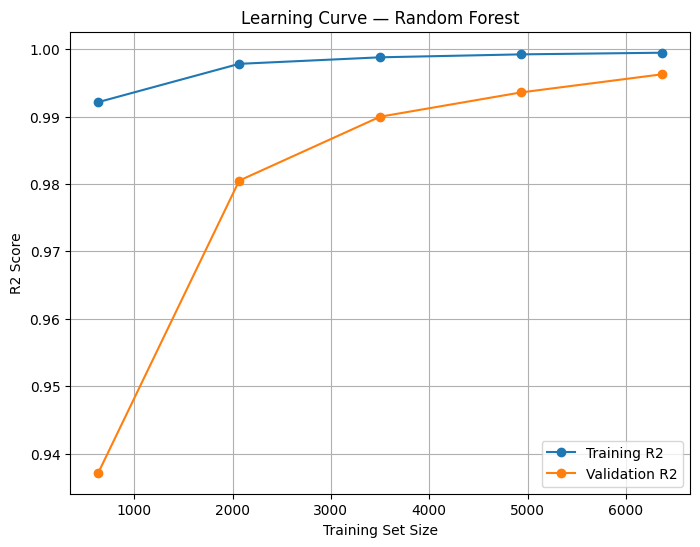

In [9]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_train,
    y_train,
    cv=3,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores,   axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training R2')
plt.plot(train_sizes, val_mean,   marker='o', label='Validation R2')
plt.xlabel('Training Set Size')
plt.ylabel('R2 Score')
plt.title('Learning Curve — Random Forest')
plt.legend()
plt.grid()
plt.show()

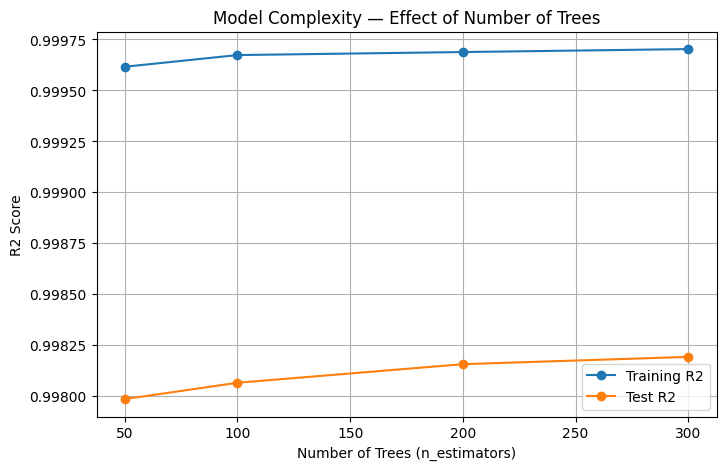

In [11]:
estimators_range  = [50, 100, 200, 300]
train_r2_scores   = []
test_r2_scores    = []

for n in estimators_range:
    model = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    train_r2_scores.append(r2_score(y_train, model.predict(X_train)))
    test_r2_scores.append(r2_score(y_test,  model.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(estimators_range, train_r2_scores, marker='o', label='Training R2')
plt.plot(estimators_range, test_r2_scores,  marker='o', label='Test R2')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('R2 Score')
plt.title('Model Complexity — Effect of Number of Trees')
plt.legend()
plt.grid()
plt.show()

In [12]:
importances = rf_model.feature_importances_
features    = X.columns

importance_df = pd.DataFrame({
    'Feature':    features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Remove top 2 most important features and retrain
top2_features  = importance_df['Feature'][:2].tolist()
print('Removing top 2 features:', top2_features)

X_reduced = df.drop(columns=[target_column] + top2_features)
y_reduced  = df[target_column]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y_reduced, test_size=0.2, random_state=42
)
scaler_r    = StandardScaler()
X_train_r   = scaler_r.fit_transform(X_train_r)
X_test_r    = scaler_r.transform(X_test_r)

rf_reduced  = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_reduced.fit(X_train_r, y_train_r)

r2_full     = r2_score(y_test, rf_model.predict(X_test))
r2_reduced  = r2_score(y_test_r, rf_reduced.predict(X_test_r))

print('\nR2 with all features:        ', round(r2_full,    6))
print('R2 after removing top 2:     ', round(r2_reduced, 6))
print('R2 drop:                     ', round(r2_full - r2_reduced, 6))

Removing top 2 features: ['GT Compressor outlet air temperature (T2) [C]', 'HP Turbine exit pressure (P48) [bar]']

R2 with all features:         0.998192
R2 after removing top 2:      0.997796
R2 drop:                      0.000396
